In [12]:
import argparse
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
import numpy as np
import matplotlib.pylab as plt
from tqdm import tqdm_notebook

In [13]:
device = 'cuda:0'

In [14]:
BS = 32
PATTERN_LEN = 4
SEQ_LEN = 8
TASK_NUM = 16
SIGMA = 0.1
E_NUM = 100
LR0 = 1.0

In [15]:
gold_params = []
X = []
Y = []
for _ in range(TASK_NUM):
    pattern = ''.join(['01'[i] for i in np.random.randint(low=0, high=2, size=(PATTERN_LEN))])
    p = -1 + 2*torch.tensor(list(map(float, pattern)))
    gold_params.append(torch.nn.Sequential(torch.nn.Linear(SEQ_LEN, SEQ_LEN - PATTERN_LEN+1), torch.nn.ReLU(), torch.nn.Linear(SEQ_LEN -  PATTERN_LEN+1, 1)))
    gold_params[-1][0].weight.data *= 0.0
    gold_params[-1][0].bias.data *= 0.0
    gold_params[-1][2].bias.data *= 0.0
    gold_params[-1][0].bias.data.fill_(-(PATTERN_LEN - 0.5))  
    gold_params[-1][2].weight.data *= 0.0
    gold_params[-1][2].weight.data += 1.0
    
    for i in range(SEQ_LEN-PATTERN_LEN+1):
        gold_params[-1][0].weight[i, i:i+PATTERN_LEN].data *= 0.0
        gold_params[-1][0].weight[i, i:i+PATTERN_LEN].data += p
    
    x = []
    y = []
    for j in range(BS*3):
        x.append(''.join(['01'[i] for i in np.random.randint(low=0, high=2, size=(SEQ_LEN))]))
        y.append(1 * (pattern in x[-1]))
    
    while sum(y[:BS]) < BS//2:
        zeros = np.where(np.array(y[:BS])==0)[0]
        j = np.random.choice(zeros, 1)[0]
        offset = np.random.randint(low=0, high=SEQ_LEN - PATTERN_LEN)
        x[j] = x[j][:offset] + pattern + x[j][offset+PATTERN_LEN:]
        y[j] = 1
    
    while sum(y[BS:2*BS]) < BS//2:
        zeros = BS + np.where(np.array(y[BS:2*BS])==0)[0]
        j = np.random.choice(zeros, 1)[0]
        offset = np.random.randint(low=0, high=SEQ_LEN - PATTERN_LEN)
        x[j] = x[j][:offset] + pattern + x[j][offset+PATTERN_LEN:]
        y[j] = 1
        
    while sum(y[2*BS:]) < BS//2:
        zeros = 2*BS + np.where(np.array(y[2*BS:])==0)[0]
        j = np.random.choice(zeros, 1)[0]
        offset = np.random.randint(low=0, high=SEQ_LEN - PATTERN_LEN)
        x[j] = x[j][:offset] + pattern + x[j][offset+PATTERN_LEN:]
        y[j] = 1
        
    x = torch.tensor([list(map(int, x[j])) for j in range(3*BS)]).float().to(device) 
    #x += torch.randn((BS*2, SEQ_LEN)).to(device) * SIGMA   
    y = torch.tensor(y).to(device)
    X.append(2*x-1.0)
    Y.append(y)
torch.cat(Y).float().mean()

tensor(0.5000, device='cuda:0')

In [16]:
with open('conv_mini_data.pckl', 'wb') as out:
    import pickle
    out.write(pickle.dumps([X, Y, gold_params]))

In [17]:
%matplotlib inline

In [18]:
# === Load the dataset (from pickle, fallback to in-memory variables) ===
import pickle
try:
    with open('conv_mini_data.pckl', 'rb') as f:
        X, Y, gold_params = pickle.load(f)
    print('loaded from conv_mini_data.pckl')
except FileNotFoundError:
    print('pickle not found, using in-memory X, Y, gold_params')
X = [x.detach().cpu() for x in X]
Y = [y.detach().cpu() for y in Y]
gold_params = [g.cpu() for g in gold_params]
print(f'TASK_NUM = {len(X)}, per-task x.shape = {X[0].shape}, y.shape = {Y[0].shape}')
print(f'overall positive fraction = {torch.cat(Y).float().mean():.3f}')


loaded from conv_mini_data.pckl
TASK_NUM = 16, per-task x.shape = torch.Size([96, 8]), y.shape = torch.Size([96])
overall positive fraction = 0.500


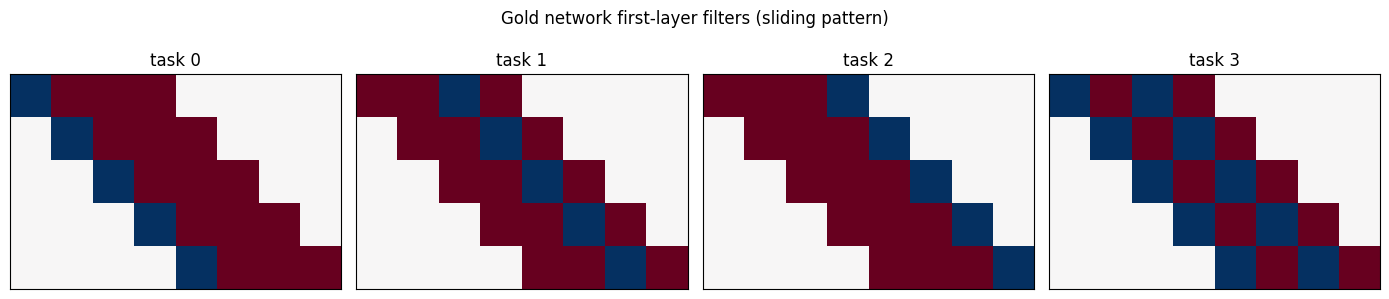

In [19]:
# === Gold network first-layer filters (sliding pattern) ===
fig, axes = plt.subplots(1, 4, figsize=(14, 3))
for i, ax in enumerate(axes):
    w = gold_params[i][0].weight.detach().cpu()  # (5, 8)
    ax.imshow(w, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(f'task {i}')
fig.suptitle('Gold network first-layer filters (sliding pattern)')
fig.tight_layout()
plt.show()


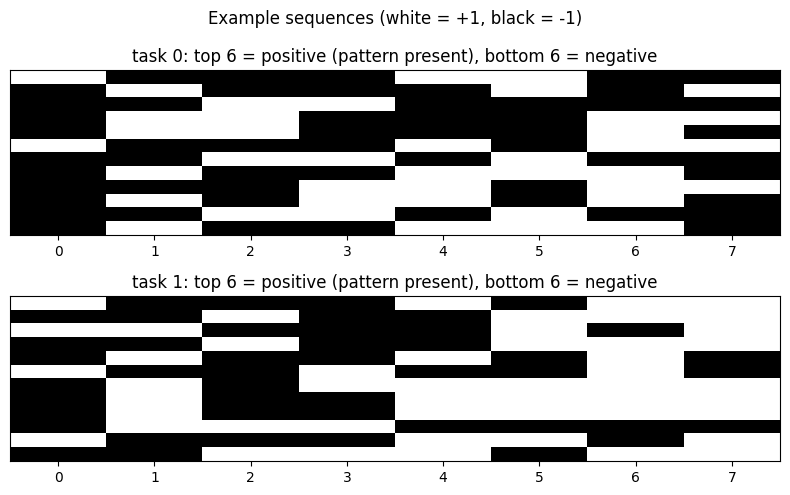

In [20]:
# === Example sequences: positives vs negatives ===
fig, axes = plt.subplots(2, 1, figsize=(8, 5))
for t, ax in enumerate(axes):
    y = Y[t]; x = X[t]
    pos = (y == 1).nonzero(as_tuple=True)[0][:6]
    neg = (y == 0).nonzero(as_tuple=True)[0][:6]
    rows = torch.cat([x[pos], x[neg]], dim=0)  # (12, 8)
    ax.imshow(rows, cmap='Greys', vmin=-1, vmax=1, aspect='auto')
    ax.set_yticks([])
    ax.set_xticks(range(8))
    ax.set_title(f'task {t}: top 6 = positive (pattern present), bottom 6 = negative')
fig.suptitle('Example sequences (white = +1, black = -1)')
fig.tight_layout()
plt.show()


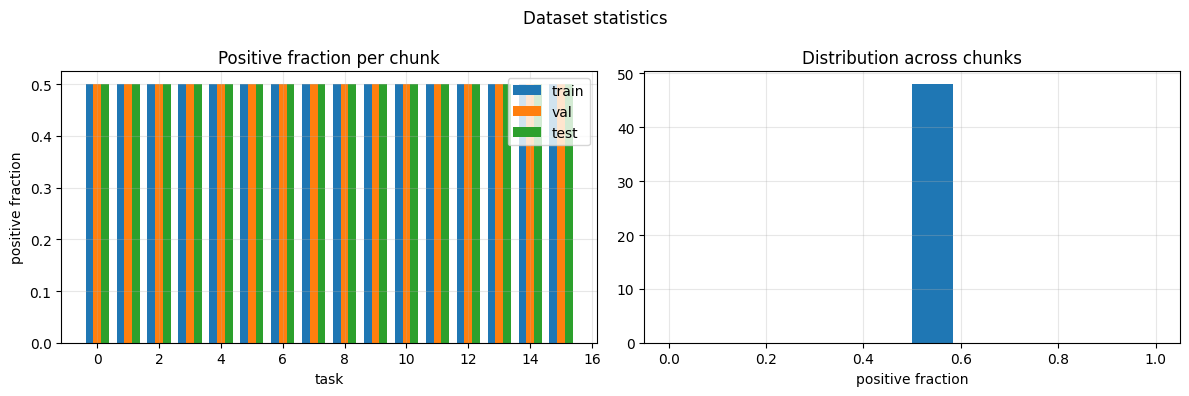

In [21]:
# === Dataset statistics: positive fraction per chunk ===
BS = 32
chunks, fracs = [], []
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for t in range(len(X)):
    y = Y[t]
    f = [y[0:BS].float().mean().item(), y[BS:2*BS].float().mean().item(), y[2*BS:].float().mean().item()]
    for c in range(3):
        chunks.append(c); fracs.append(f[c])
    for c in range(3):
        axes[0].bar(t + (c - 1) * 0.25, f[c], width=0.25, color=f'C{c}', label=('train','val','test')[c] if t == 0 else None)
axes[0].set_xlabel('task'); axes[0].set_ylabel('positive fraction')
axes[0].set_title('Positive fraction per chunk'); axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].hist(fracs, bins=12)
axes[1].set_xlabel('positive fraction'); axes[1].set_title('Distribution across chunks'); axes[1].grid(alpha=0.3)
fig.suptitle('Dataset statistics')
fig.tight_layout()
plt.show()


task  0: gold acc = 1.0000
task  1: gold acc = 1.0000
task  2: gold acc = 1.0000
task  3: gold acc = 1.0000
task  4: gold acc = 1.0000
task  5: gold acc = 1.0000
task  6: gold acc = 1.0000
task  7: gold acc = 1.0000
task  8: gold acc = 1.0000
task  9: gold acc = 1.0000
task 10: gold acc = 1.0000
task 11: gold acc = 1.0000
task 12: gold acc = 1.0000
task 13: gold acc = 1.0000
task 14: gold acc = 1.0000
task 15: gold acc = 1.0000
mean acc = 1.0000


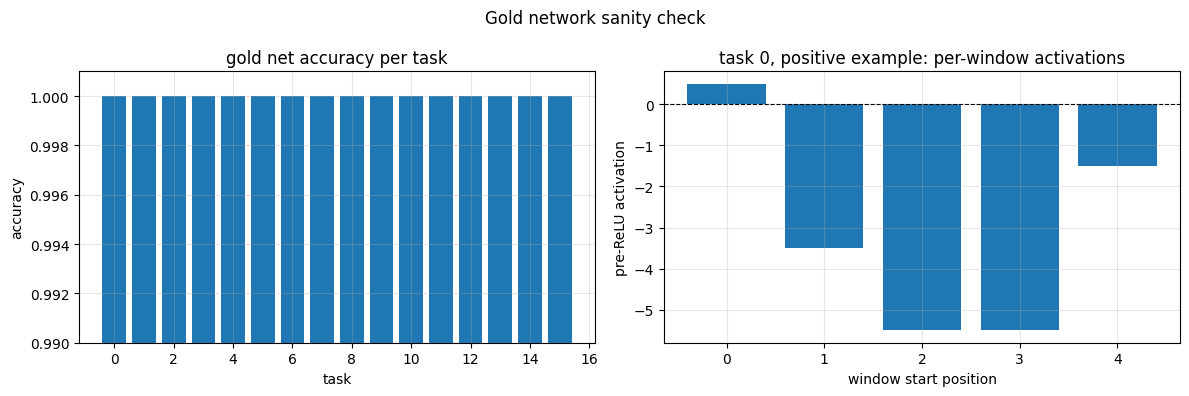

In [22]:
# === Sanity check: gold network accuracy (should be 100%) ===
accs = []
with torch.no_grad():
    for t in range(len(X)):
        out = gold_params[t](X[t]).squeeze(-1)
        pred = (out > 0).float()
        acc = (pred == Y[t]).float().mean().item()
        accs.append(acc)
        print(f'task {t:2d}: gold acc = {acc:.4f}')
print(f'mean acc = {np.mean(accs):.4f}')
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(range(len(accs)), accs)
axes[0].set_ylim(0.99, 1.001); axes[0].set_xlabel('task'); axes[0].set_ylabel('accuracy')
axes[0].set_title('gold net accuracy per task'); axes[0].grid(alpha=0.3)
x0 = X[0][(Y[0] == 1).nonzero(as_tuple=True)[0][0]]
h = gold_params[0][0](x0).detach().cpu().numpy()  # pre-ReLU, 5 windows
axes[1].bar(range(5), h)
axes[1].axhline(0, color='k', linestyle='--', linewidth=0.8)
axes[1].set_xlabel('window start position'); axes[1].set_ylabel('pre-ReLU activation')
axes[1].set_title('task 0, positive example: per-window activations'); axes[1].grid(alpha=0.3)
fig.suptitle('Gold network sanity check')
fig.tight_layout()
plt.show()


task  0: pattern = 0111
task  1: pattern = 1101
task  2: pattern = 1110
task  3: pattern = 0101
task  4: pattern = 1011
task  5: pattern = 0001
task  6: pattern = 1110
task  7: pattern = 1111
task  8: pattern = 1101
task  9: pattern = 1111
task 10: pattern = 0000
task 11: pattern = 0010
task 12: pattern = 0011
task 13: pattern = 0111
task 14: pattern = 0110
task 15: pattern = 0011
unique patterns = 11


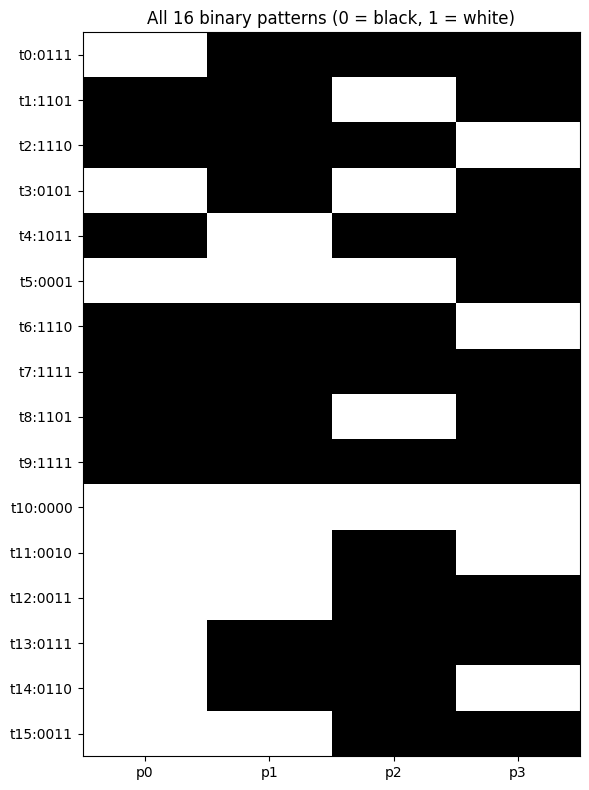

In [23]:
# === All 16 patterns recovered from gold weights ===
patterns = []
for t in range(len(X)):
    p = gold_params[t][0].weight.detach()[0, 0:4]   # +-1 pattern (shifted copies -> take row 0)
    pat = (p > 0).int().tolist()                      # back to 0/1 bits
    patterns.append(pat)
pat_strs = [''.join(str(b) for b in pat) for pat in patterns]
for t, s in enumerate(pat_strs):
    print(f'task {t:2d}: pattern = {s}')
print(f'unique patterns = {len(set(pat_strs))}')

fig, ax = plt.subplots(figsize=(6, 8))
im = ax.imshow(np.array(patterns), cmap='Greys', vmin=0, vmax=1, aspect='auto')
ax.set_xticks(range(4)); ax.set_xticklabels([f'p{i}' for i in range(4)])
ax.set_yticks(range(len(patterns))); ax.set_yticklabels([f't{t}:{s}' for t, s in enumerate(pat_strs)])
ax.set_title('All 16 binary patterns (0 = black, 1 = white)')
fig.tight_layout()
plt.show()

/var/tmp/ipykernel_2489490/3489846925.py:14: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


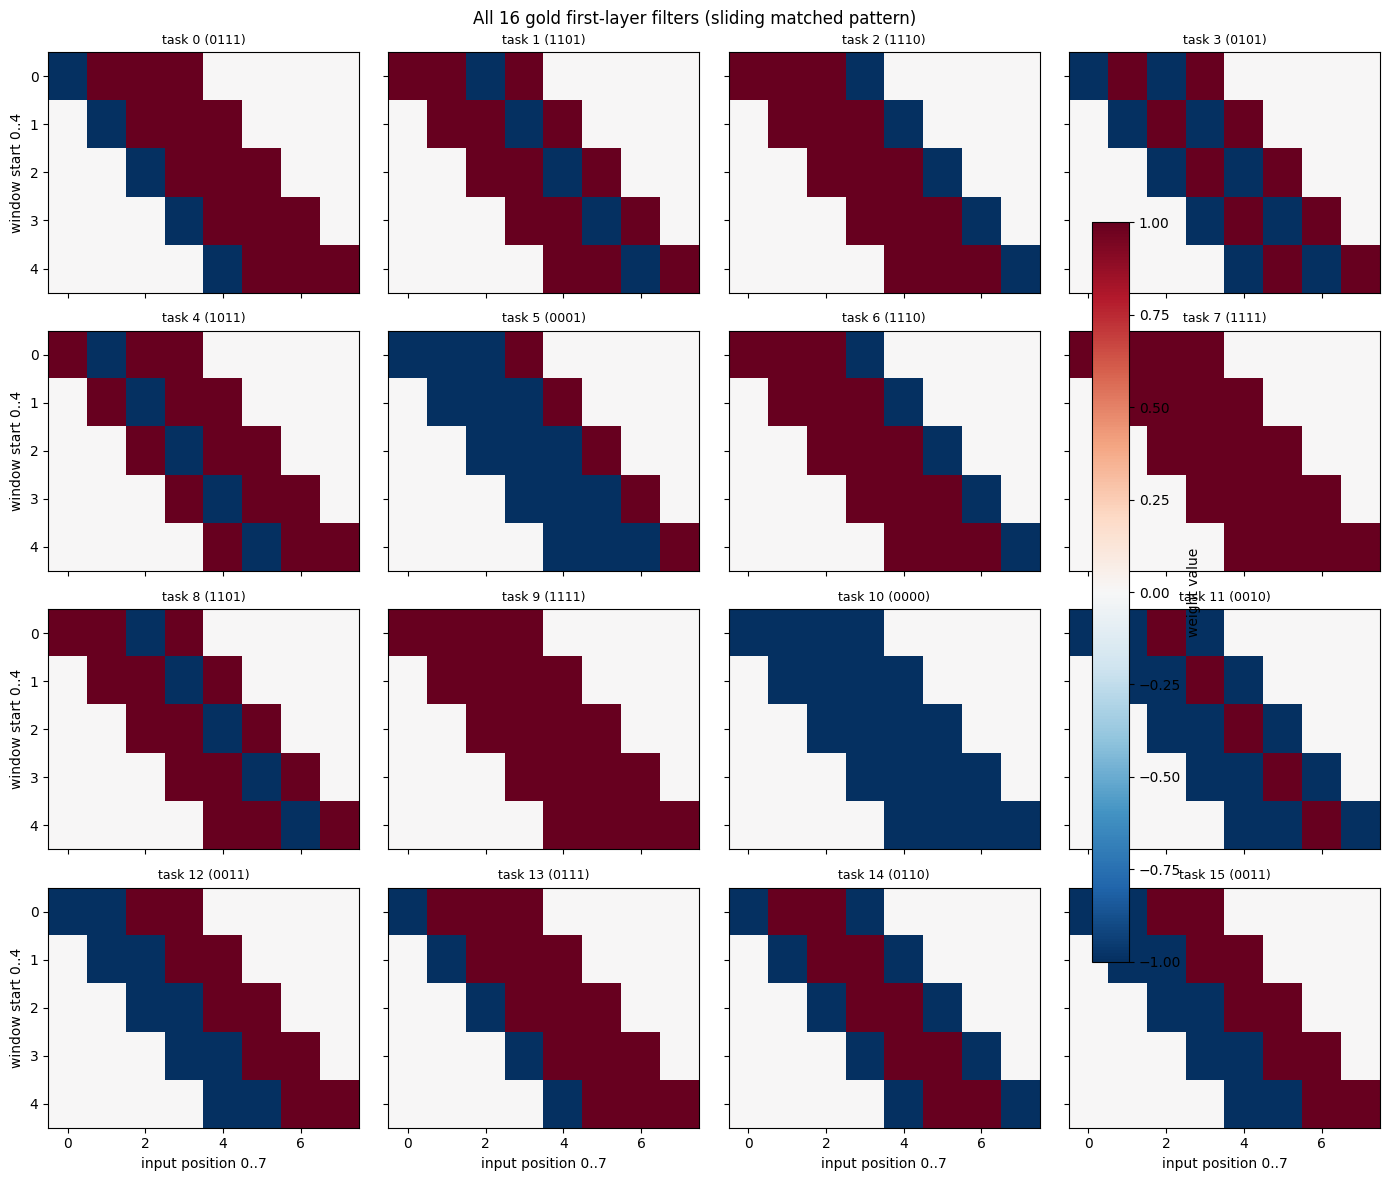

In [24]:
# === All 16 gold first-layer filters (sliding pattern) ===
fig, axes = plt.subplots(4, 4, figsize=(14, 12), sharex=True, sharey=True)
im = None
for t, ax in enumerate(axes.flat):
    w = gold_params[t][0].weight.detach().cpu().numpy()   # (5, 8) = (window_start, input_pos)
    im = ax.imshow(w, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
    ax.set_title(f'task {t} ({pat_strs[t]})', fontsize=9)
for ax in axes[-1, :]:
    ax.set_xlabel('input position 0..7')
for ax in axes[:, 0]:
    ax.set_ylabel('window start 0..4')
fig.colorbar(im, ax=axes, shrink=0.8, label='weight value')
fig.suptitle('All 16 gold first-layer filters (sliding matched pattern)')
fig.tight_layout()
plt.show()

positive samples with 0 / 1 / 2+ matches: [0, 679, 89] (total positives = 768)


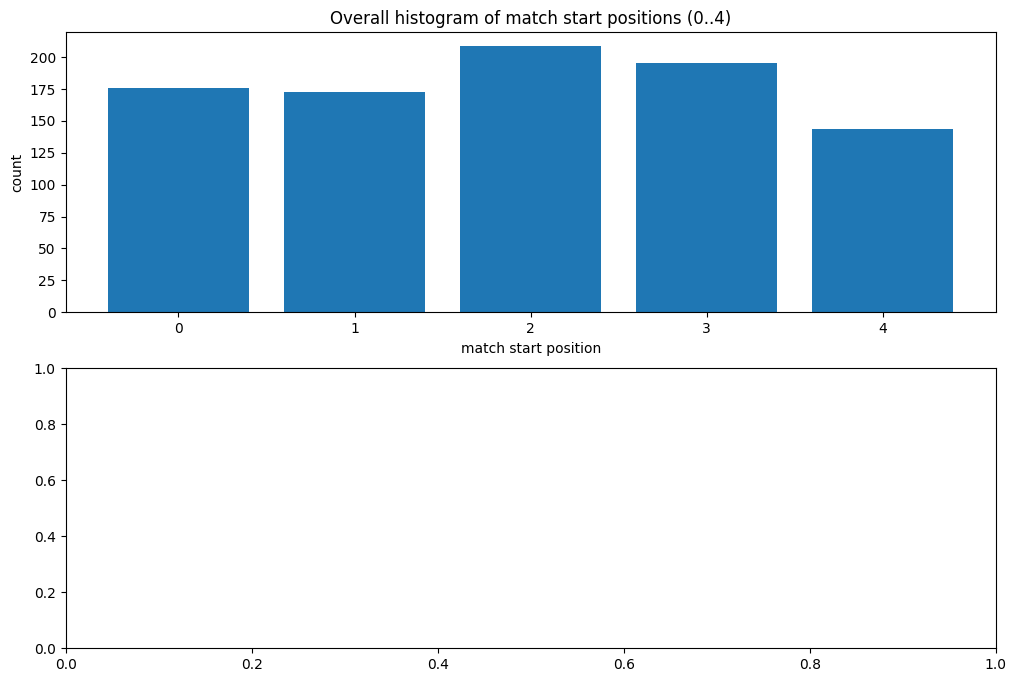

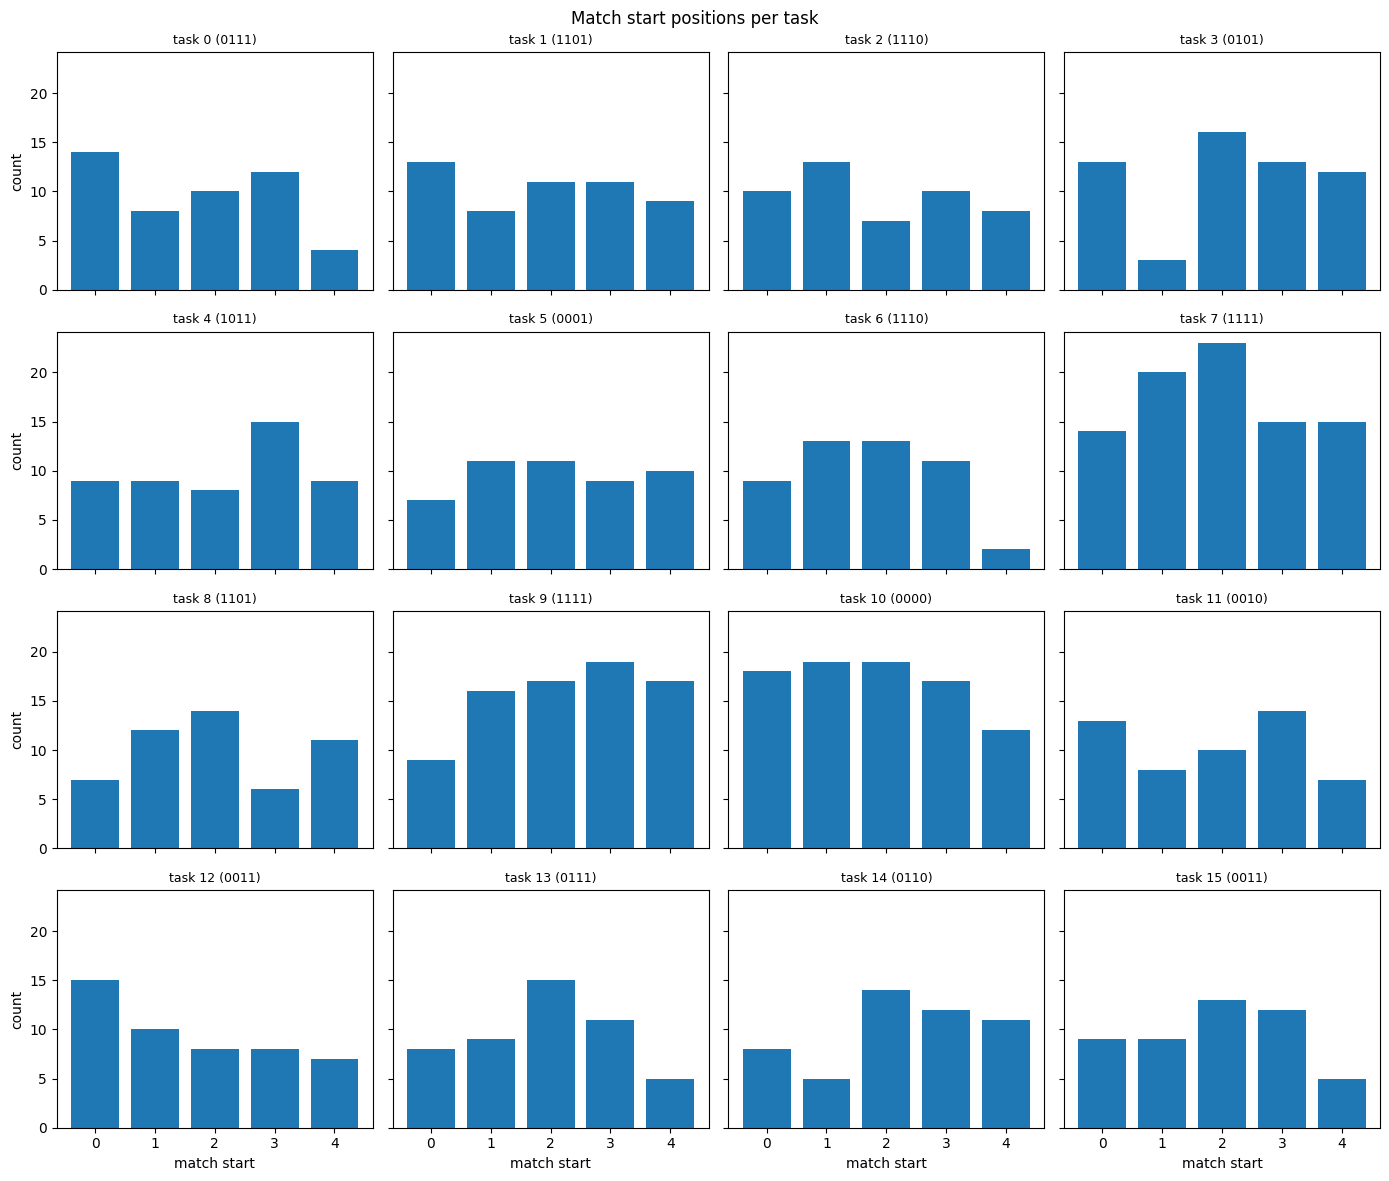

In [25]:
# === Pattern match positions ===
bits = lambda x: (x > 0).int()                       # +-1 -> 0/1
all_matches = []                                      # per task list of match start positions (flattened)
n_pos_match_hist = np.zeros(3, dtype=int)             # positives with 0/1/2+ matches
for t in range(len(X)):
    xb = bits(X[t])                                   # (96, 8)
    matches = []
    for i in range(96):
        starts = [s for s in range(SEQ_LEN - PATTERN_LEN + 1)
                  if (xb[i, s:s+PATTERN_LEN] == torch.tensor(patterns[t])).all().item()]
        matches.append(starts)
        if Y[t][i].item() == 1:
            k = len(starts)
            n_pos_match_hist[min(k, 2)] += 1
    all_matches.append(matches)
n_pos = int(torch.cat(Y).sum().item())
print('positive samples with 0 / 1 / 2+ matches:', n_pos_match_hist.tolist(), f'(total positives = {n_pos})')

# overall histogram of match start positions
starts_all = [s for t in range(len(X)) for m in all_matches[t] for s in m]
fig, axes = plt.subplots(2, 1, figsize=(12, 8))
axes[0].hist(starts_all, bins=range(SEQ_LEN - PATTERN_LEN + 2), align='left', rwidth=0.8, color='C0')
axes[0].set_xticks(range(SEQ_LEN - PATTERN_LEN + 1))
axes[0].set_xlabel('match start position'); axes[0].set_ylabel('count')
axes[0].set_title('Overall histogram of match start positions (0..4)')

# 4x4 small-multiples per task
gax = axes[1]
axs = []
fig2, axes2 = plt.subplots(4, 4, figsize=(14, 12), sharex=True, sharey=True)
for t, ax in enumerate(axes2.flat):
    starts_t = [s for m in all_matches[t] for s in m]
    ax.hist(starts_t, bins=range(SEQ_LEN - PATTERN_LEN + 2), align='left', rwidth=0.8)
    ax.set_title(f'task {t} ({pat_strs[t]})', fontsize=9)
    ax.set_xticks(range(SEQ_LEN - PATTERN_LEN + 1))
for ax in axes2[-1, :]:
    ax.set_xlabel('match start')
for ax in axes2[:, 0]:
    ax.set_ylabel('count')
fig2.suptitle('Match start positions per task')
fig2.tight_layout()
plt.show()

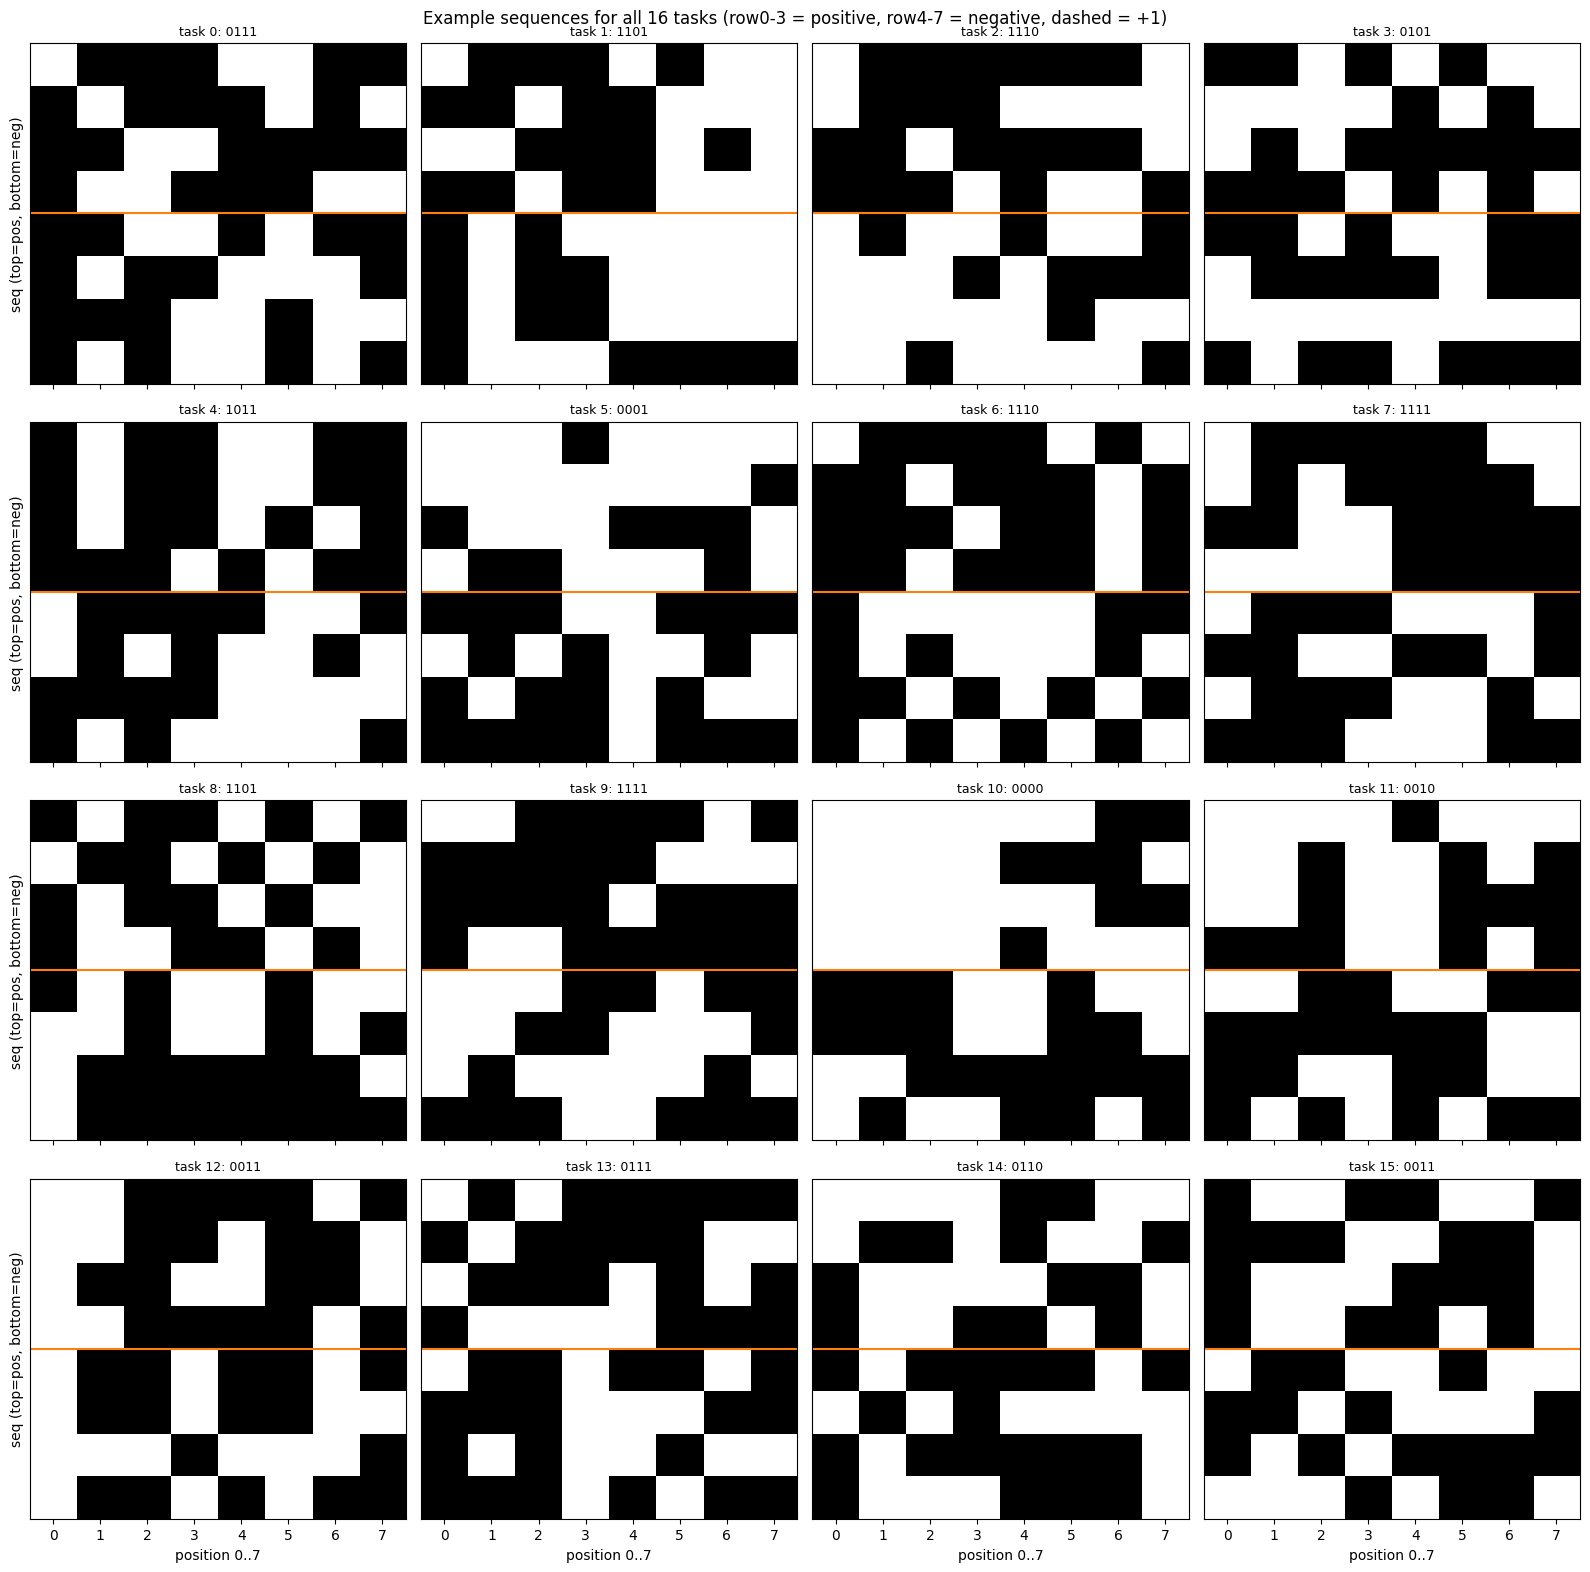

In [26]:
# === Example sequences for more tasks (all 16) ===
fig, axes = plt.subplots(4, 4, figsize=(16, 16), sharex=True, sharey=True)
for t, ax in enumerate(axes.flat):
    y = Y[t]; x = X[t]
    pos = (y == 1).nonzero(as_tuple=True)[0][:4]
    neg = (y == 0).nonzero(as_tuple=True)[0][:4]
    rows = torch.cat([x[pos], x[neg]], dim=0).detach().cpu().numpy()   # (8, 8): 4 pos + 4 neg
    ax.imshow(rows, cmap='Greys', vmin=-1, vmax=1, aspect='auto')
    ax.set_xticks(range(8))
    ax.set_yticks([])
    ax.axhline(3.5, color='C1', linewidth=1.5)
    ax.set_title(f'task {t}: {pat_strs[t]}', fontsize=9)
for ax in axes[-1, :]:
    ax.set_xlabel('position 0..7')
for ax in axes[:, 0]:
    ax.set_ylabel('seq (top=pos, bottom=neg)')
fig.suptitle('Example sequences for all 16 tasks (row0-3 = positive, row4-7 = negative, dashed = +1)')
fig.tight_layout()
plt.show()

unique patterns = 11 / 16
pairwise Hamming distances, min/mean/max = 0 1.942 4


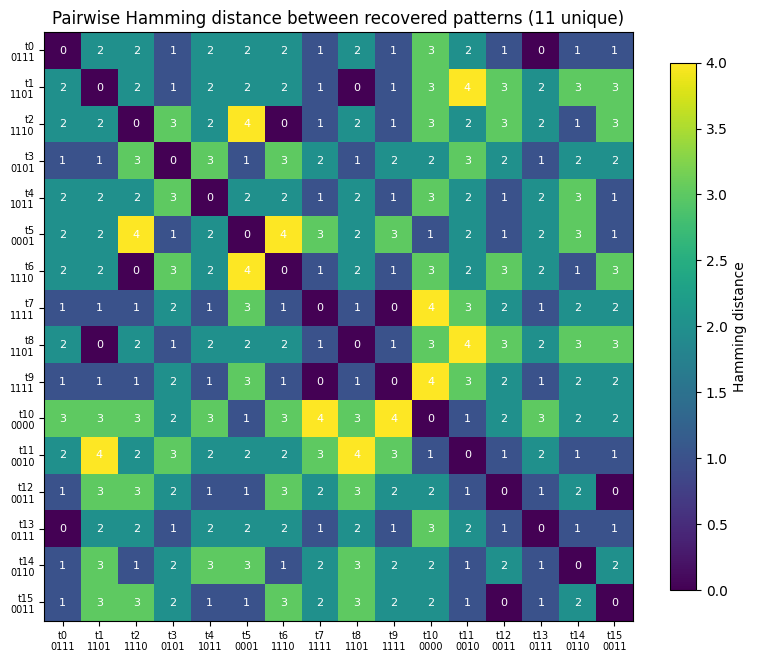

In [27]:
# === Pattern diversity (pairwise Hamming distance) ===
P = np.array(patterns, dtype=int)                       # (16, 4)
D = (P[:, None, :] != P[None, :, :]).sum(axis=-1).astype(int)
uniq = len(set(map(tuple, P)))
print(f'unique patterns = {uniq} / {len(P)}')
print('pairwise Hamming distances, min/mean/max =',
      D[~np.eye(len(P), dtype=bool)].min(),
      round(D[~np.eye(len(P), dtype=bool)].mean(), 3),
      D[~np.eye(len(P), dtype=bool)].max())
fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(D, cmap='viridis', vmin=0, vmax=4)
ax.set_xticks(range(len(P))); ax.set_xticklabels([f't{t}\n{s}' for t, s in enumerate(pat_strs)], fontsize=7)
ax.set_yticks(range(len(P))); ax.set_yticklabels([f't{t}\n{s}' for t, s in enumerate(pat_strs)], fontsize=7)
for i in range(len(P)):
    for j in range(len(P)):
        ax.text(j, i, D[i, j], ha='center', va='center', color='white', fontsize=8)
ax.set_title(f'Pairwise Hamming distance between recovered patterns ({uniq} unique)')
fig.colorbar(im, ax=ax, shrink=0.8, label='Hamming distance')
fig.tight_layout()
plt.show()

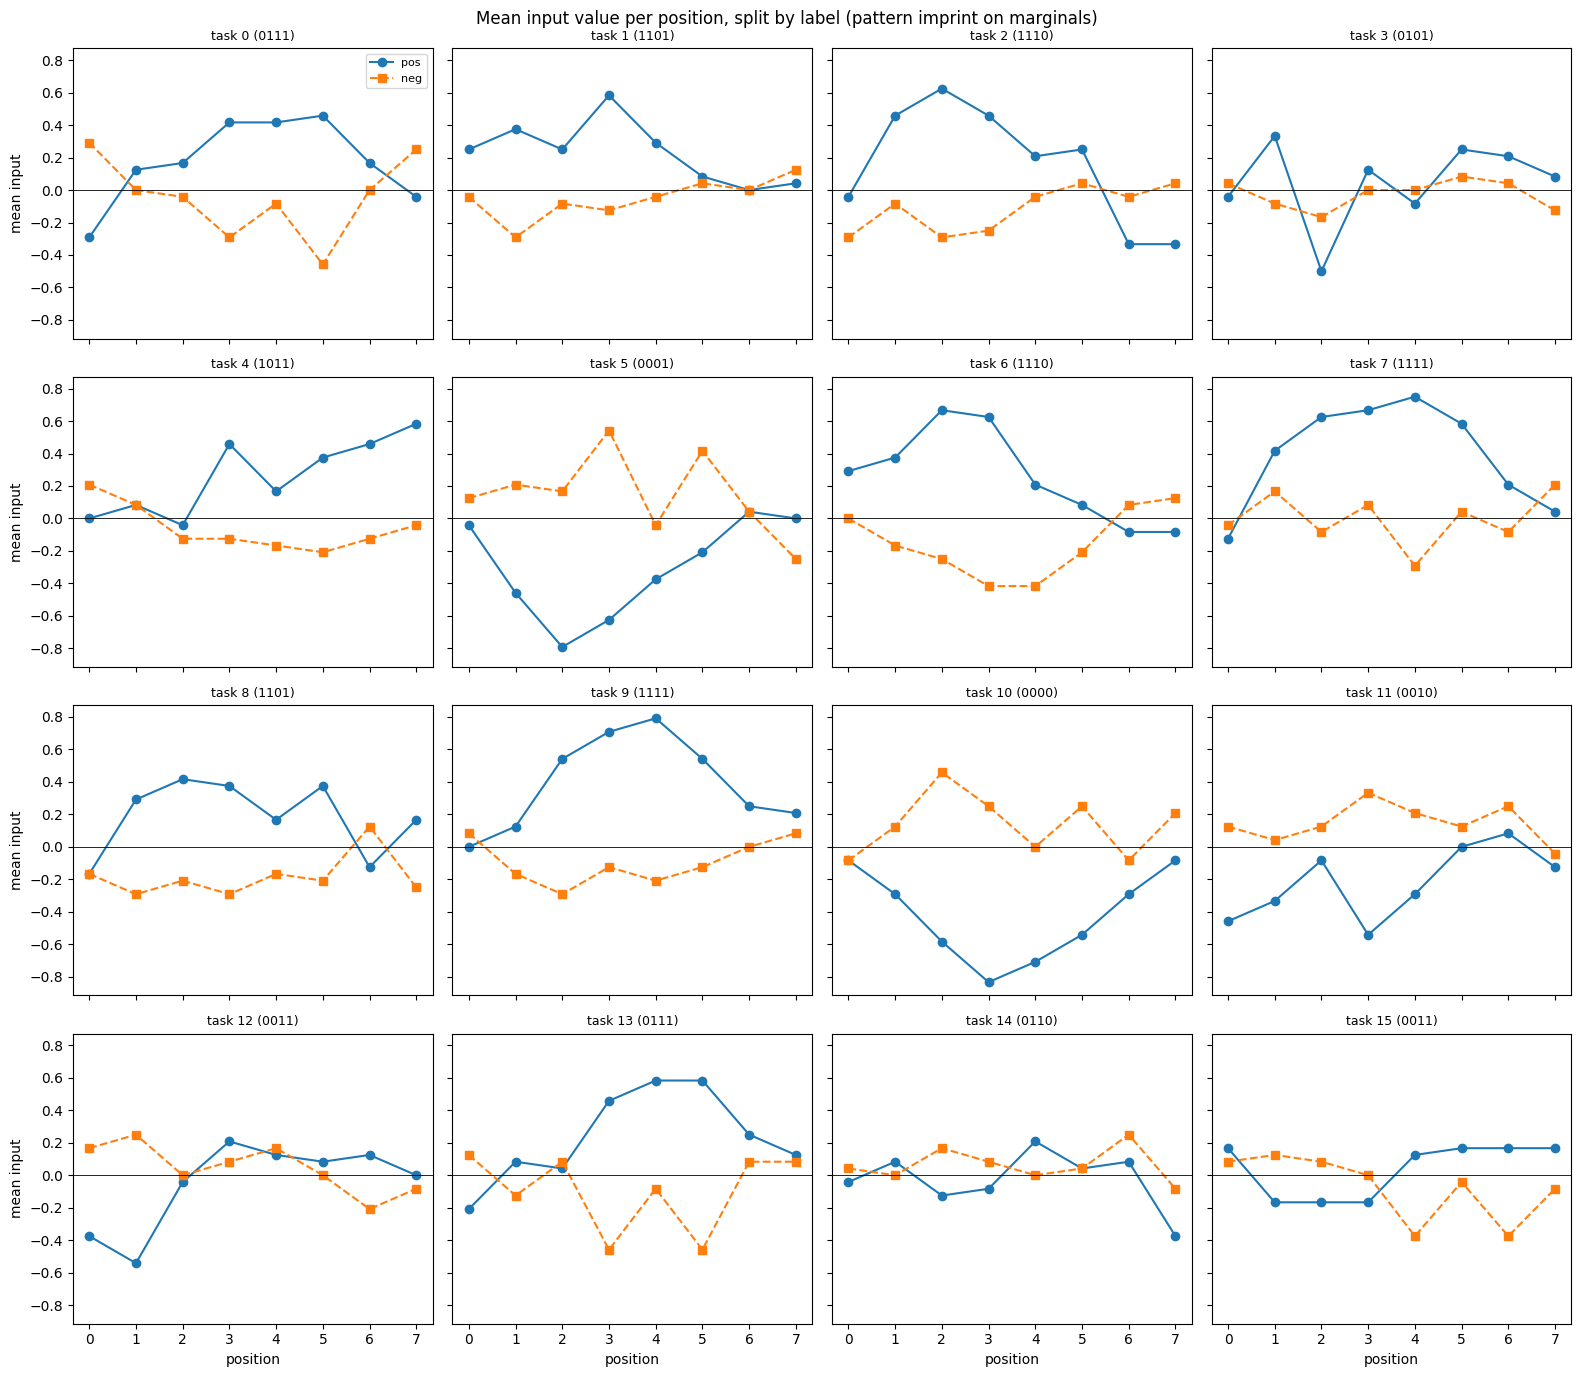

In [28]:
# === Position-wise input statistics by class ===
fig, axes = plt.subplots(4, 4, figsize=(16, 14), sharex=True, sharey=True)
for t, ax in enumerate(axes.flat):
    x = X[t].detach().cpu().numpy()
    y = Y[t].detach().cpu().numpy()
    pos = x[y == 1].mean(axis=0)
    neg = x[y == 0].mean(axis=0)
    ax.plot(range(SEQ_LEN), pos, 'o-', color='C0', label='pos')
    ax.plot(range(SEQ_LEN), neg, 's--', color='C1', label='neg')
    ax.axhline(0, color='k', linewidth=0.6)
    ax.set_title(f'task {t} ({pat_strs[t]})', fontsize=9)
    if t == 0:
        ax.legend(fontsize=8)
for ax in axes[-1, :]:
    ax.set_xlabel('position')
for ax in axes[:, 0]:
    ax.set_ylabel('mean input')
fig.suptitle('Mean input value per position, split by label (pattern imprint on marginals)')
fig.tight_layout()
plt.show()

/var/tmp/ipykernel_2489490/2239630724.py:20: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


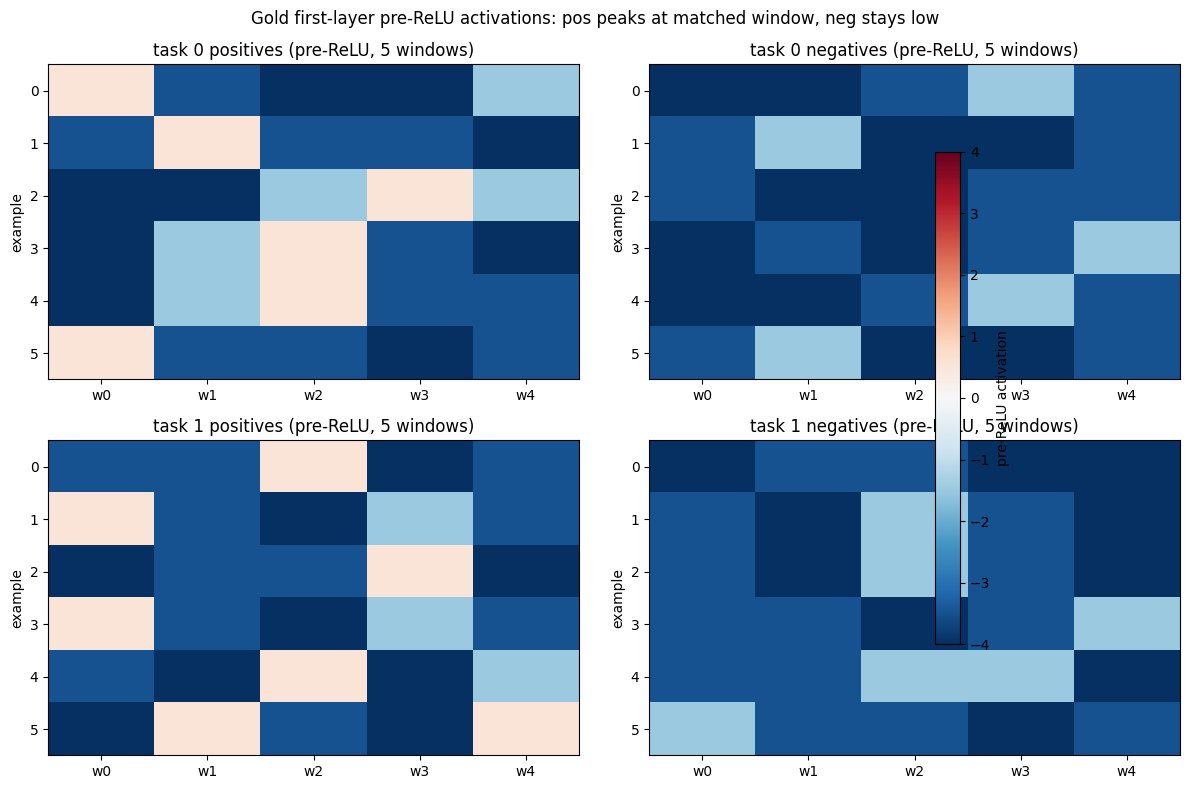

: 

In [ ]:
# === Gold activations: positives vs negatives (tasks 0, 1) ===
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for r, t in enumerate([0, 1]):
    x = X[t]; y = Y[t]
    with torch.no_grad():
        pre = gold_params[t][0](x).detach().cpu().numpy()   # (96, 5) pre-ReLU per window
    pos = pre[y == 1][:6]
    neg = pre[y == 0][:6]
    # first column: positive examples
    axes[r, 0].imshow(pos, cmap='RdBu_r', vmin=-4, vmax=4, aspect='auto')
    axes[r, 0].set_title(f'task {t} positives (pre-ReLU, 5 windows)')
    # second column: negative examples
    im = axes[r, 1].imshow(neg, cmap='RdBu_r', vmin=-4, vmax=4, aspect='auto')
    axes[r, 1].set_title(f'task {t} negatives (pre-ReLU, 5 windows)')
    for ax in (axes[r, 0], axes[r, 1]):
        ax.set_xticks(range(5)); ax.set_xticklabels([f'w{s}' for s in range(5)])
        ax.set_ylabel('example')
fig.colorbar(im, ax=axes, shrink=0.8, label='pre-ReLU activation')
fig.suptitle('Gold first-layer pre-ReLU activations: pos peaks at matched window, neg stays low')
fig.tight_layout()
plt.show()